# Exploratory Data Analysis (EDA) - Chronic Kidney Disease Dataset
This notebook performs comprehensive EDA on the cleaned kidney disease dataset to uncover patterns, feature correlations, and target distribution before building ML models.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# add  Project root path
sys.path.append(os.path.abspath('..'))

from src.data_loader import DataLoader
from src.data_cleaner import DataCleaner

# Plot styles setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# 1. Load raw dataset
loader = DataLoader('../data/raw/kidney_disease (1).csv')
df_raw = loader.load_data()

# 2. Clean dataset
cleaner = DataCleaner()
df_clean = cleaner.clean_data(df_raw)

print("Cleaned Data Shape:", df_clean.shape)
df_clean.head()

Cleaned Data Shape: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,121.0,...,38.0,6000.0,4.8,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,4.8,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,1


C:\Users\wajiz.pk\AppData\Local\Temp\ipykernel_1692\405033628.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='classification', data=df_clean, palette=['#4CAF50', '#F44336'])


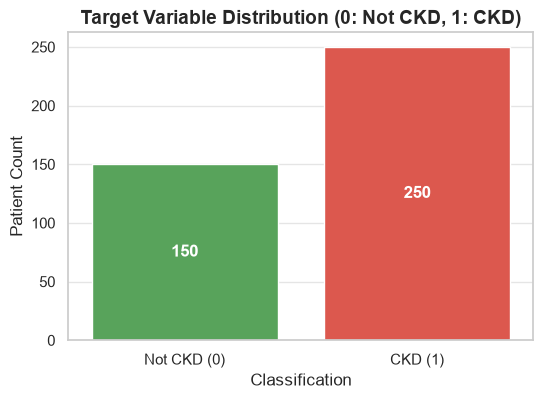

In [3]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='classification', data=df_clean, palette=['#4CAF50', '#F44336'])
plt.title('Target Variable Distribution (0: Not CKD, 1: CKD)', fontsize=14, fontweight='bold')
plt.xlabel('Classification')
plt.ylabel('Patient Count')
plt.xticks(ticks=[0, 1], labels=['Not CKD (0)', 'CKD (1)'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.show()

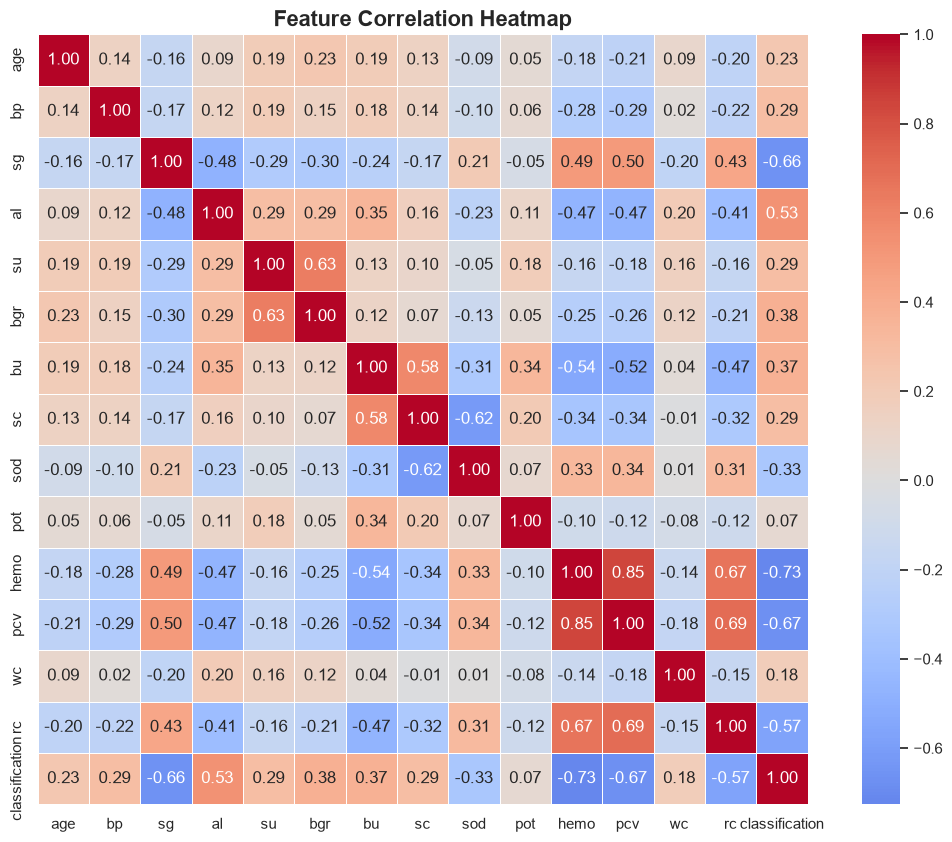

In [4]:
plt.figure(figsize=(14, 10))
numeric_df = df_clean.select_dtypes(include=['number'])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

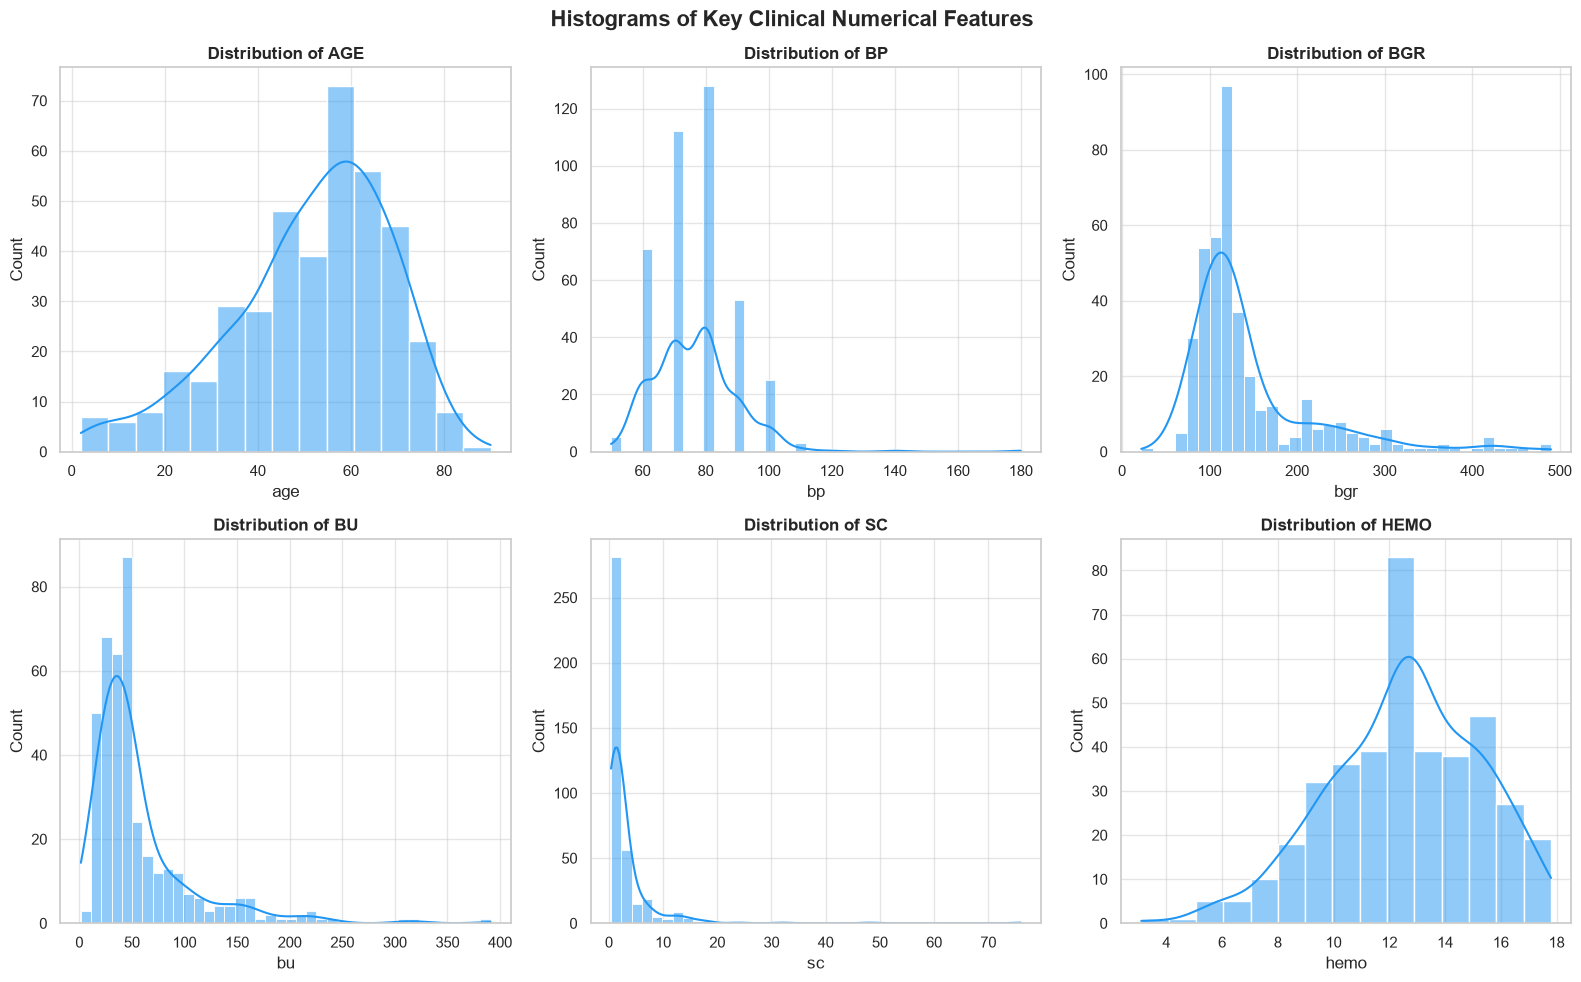

In [5]:
key_num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'hemo']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='#2196F3')
    axes[i].set_title(f'Distribution of {col.upper()}', fontweight='bold')

plt.suptitle('Histograms of Key Clinical Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\wajiz.pk\AppData\Local\Temp\ipykernel_1692\1567363965.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y=col, data=df_clean, ax=axes[i], palette=['#4CAF50', '#F44336'])
C:\Users\wajiz.pk\AppData\Local\Temp\ipykernel_1692\1567363965.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(['Not CKD', 'CKD'])
C:\Users\wajiz.pk\AppData\Local\Temp\ipykernel_1692\1567363965.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y=col, data=df_clean, ax=axes[i], palette=['#4CAF50', '#F44336'])
C:\Users\wajiz.pk

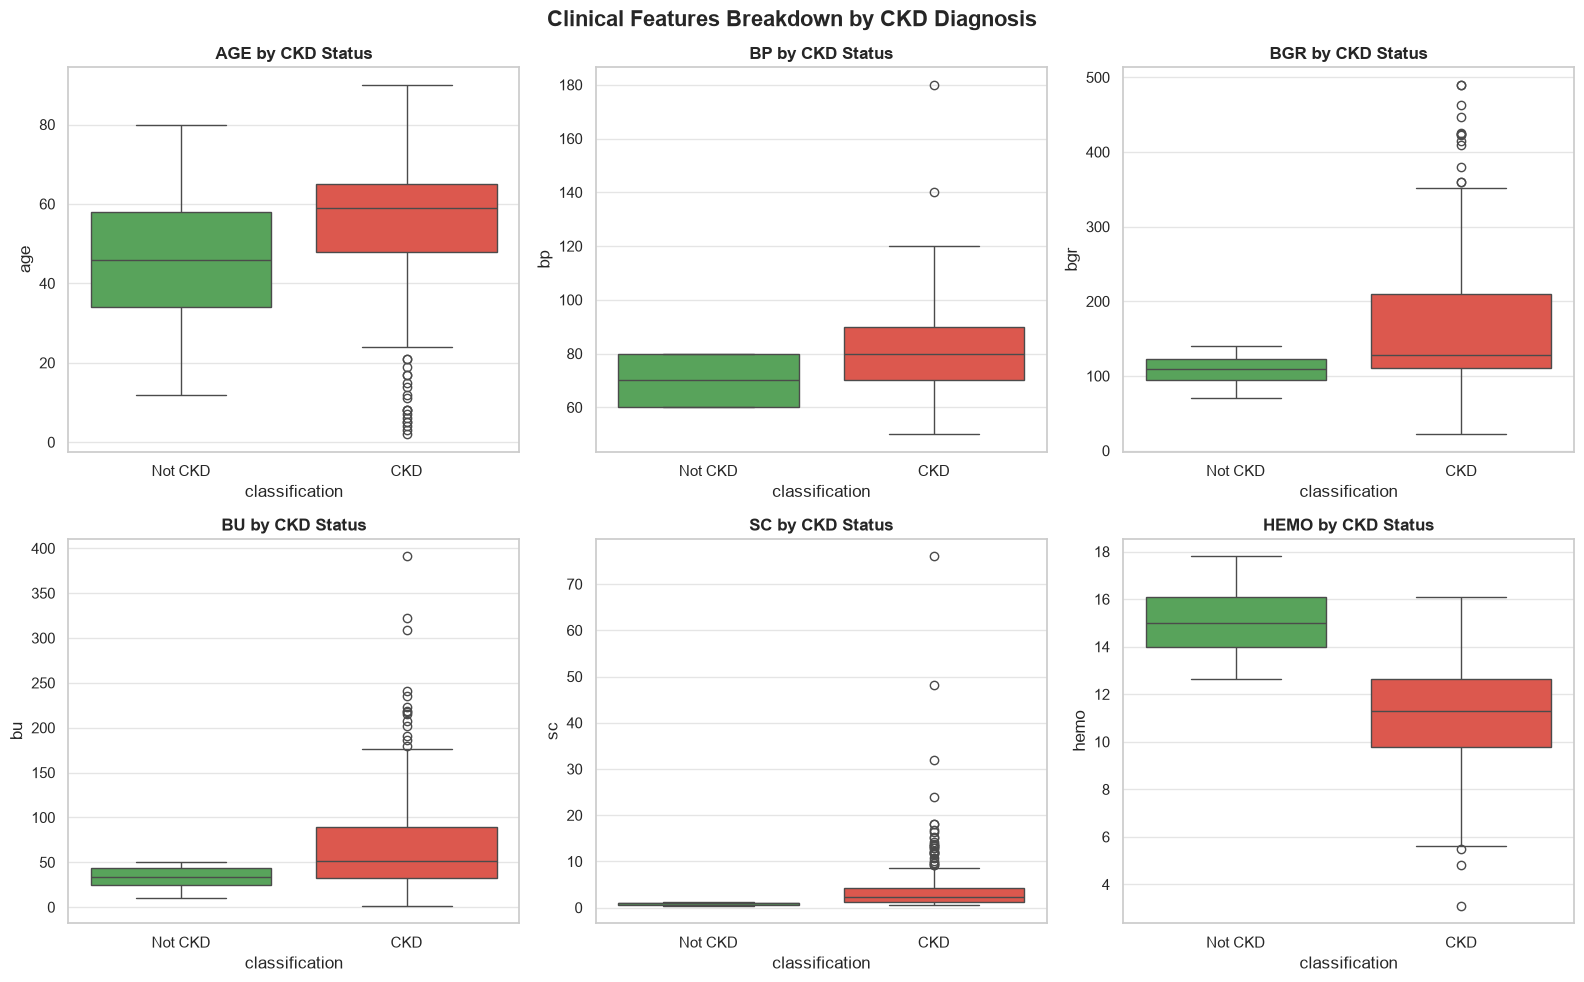

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    sns.boxplot(x='classification', y=col, data=df_clean, ax=axes[i], palette=['#4CAF50', '#F44336'])
    axes[i].set_title(f'{col.upper()} by CKD Status', fontweight='bold')
    axes[i].set_xticklabels(['Not CKD', 'CKD'])

plt.suptitle('Clinical Features Breakdown by CKD Diagnosis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Output Folder Banao
OUTPUT_DIR = os.path.abspath('../output/figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Function to save plots easily
def save_plot(filename):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved: {path}")

#Graph 1
plt.figure(figsize=(6, 4))
sns.countplot(x='classification', data=df_clean, palette=['#4CAF50', '#F44336'])
plt.title('Target Variable Distribution (0: Not CKD, 1: CKD)', fontsize=12, fontweight='bold')
save_plot('target_distribution.png')

# Graph 2: Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_clean.select_dtypes(include=['number']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
save_plot('correlation_heatmap.png')

#Graph 3: Histograms
key_num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'hemo']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(key_num_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='#2196F3')
    axes[i].set_title(f'Distribution of {col.upper()}')
plt.tight_layout()
save_plot('numerical_distributions.png')

# Graph 4: Boxplot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(key_num_cols):
    sns.boxplot(x='classification', y=col, data=df_clean, ax=axes[i], palette=['#4CAF50', '#F44336'])
    axes[i].set_title(f'{col.upper()} by CKD Status')
    axes[i].set_xticklabels(['Not CKD', 'CKD'])
plt.tight_layout()
save_plot('boxplots_by_target.png')

print("\n✅ figures saved ")


C:\Users\wajiz.pk\AppData\Local\Temp\ipykernel_1692\3558986833.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='classification', data=df_clean, palette=['#4CAF50', '#F44336'])


Saved: C:\Users\wajiz.pk\PycharmProjects\Task1 ML pipeline\output\figures\target_distribution.png
Saved: C:\Users\wajiz.pk\PycharmProjects\Task1 ML pipeline\output\figures\correlation_heatmap.png
Saved: C:\Users\wajiz.pk\PycharmProjects\Task1 ML pipeline\output\figures\numerical_distributions.png


C:\Users\wajiz.pk\AppData\Local\Temp\ipykernel_1692\3558986833.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y=col, data=df_clean, ax=axes[i], palette=['#4CAF50', '#F44336'])
C:\Users\wajiz.pk\AppData\Local\Temp\ipykernel_1692\3558986833.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(['Not CKD', 'CKD'])
C:\Users\wajiz.pk\AppData\Local\Temp\ipykernel_1692\3558986833.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y=col, data=df_clean, ax=axes[i], palette=['#4CAF50', '#F44336'])
C:\Users\wajiz

Saved: C:\Users\wajiz.pk\PycharmProjects\Task1 ML pipeline\output\figures\boxplots_by_target.png

✅ figures saved 


## Key Takeaways from EDA:
1. **Hemoglobin (hemo)**: Low hemoglobin levels are strongly associated with Chronic Kidney Disease.
2. **Serum Creatinine (sc) & Blood Urea (bu)**: Significantly higher levels in patients with CKD.
3. **Blood Glucose (bgr)**: High glucose levels (diabetes indicator) strongly correlate with kidney issues.